Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.18,31
,2000,0,0.20,31
,2000,0,0.17,31
,2000,0,0.17,31


Output()

Base 145.98787025916727 195.66941970338797 243.63951952760974


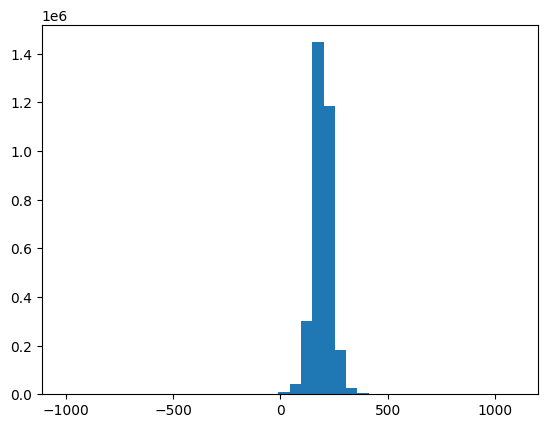

In [10]:
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt
import xarray as xr # Import xarray for explicit dataset construction

np.random.seed(42)

n=800
X=np.random.randn(n,4)
cols=["preco","gasto_ads","temperatura","eh_feriado"]
y=200-30*X[:,0]+15*X[:,1]+8*X[:,2]+40*X[:,3]+np.random.normal(0,15,n)
df=pd.DataFrame(X,columns=cols)
df["vendas"]=y

Xm,Xs=X.mean(0),X.std(0)
Xn=(X-Xm)/Xs

with pm.Model() as model:
    # Explicitly define dimensions for X_data to prevent MissingDimensionsError
    Xd=pm.Data("X_data",Xn, dims=['data_index', 'features'])
    w1=pm.Normal("w1",0,1,shape=(4,16), dims=["features", "hidden_units_l1"])
    b1=pm.Normal("b1",0,1,shape=(16,), dims=["hidden_units_l1"])
    w2=pm.Normal("w2",0,1,shape=(16,1), dims=["hidden_units_l1", "output_units"])
    b2=pm.Normal("b2",0,1)

    h=pt.tanh(pt.dot(Xd,w1)+b1)
    mu=pt.flatten(pt.dot(h,w2)+b2)

    sigma=pm.HalfNormal("sigma",20)
    pm.StudentT("obs",nu=5,mu=mu,sigma=sigma,observed=y)

    trace=pm.sample(1000,tune=1000,target_accept=0.9,chains=4, nuts_sampler='nutpie')

def gerar_cenario(nome,x):
    xn=(x-Xm)/Xs
    with model:
        pm.set_data({"X_data":xn})
        ppc=pm.sample_posterior_predictive(trace,var_names=["obs"])
    am=ppc.posterior_predictive["obs"].values.flatten()
    p10,p50,p90=np.percentile(am,[10,50,90])
    print(nome,p10,p50,p90)
    return am

base=gerar_cenario("Base",Xm.reshape(1,-1))
plt.hist(base,bins=40)
plt.show()

# Create a new InferenceData object with only the posterior and posterior_predictive groups,
# ensuring all data are standard NumPy arrays to avoid serialization issues.
new_idata_groups = {}

if hasattr(trace, 'posterior'):
    cleaned_posterior_data_vars = {}
    for var_name in trace.posterior.data_vars:
        # Convert values to NumPy arrays explicitly while preserving dims
        cleaned_posterior_data_vars[var_name] = (
            trace.posterior[var_name].dims,
            np.asarray(trace.posterior[var_name].values)
        )
    # Create a new xarray Dataset from the cleaned data_vars and original coords/attrs
    posterior_ds_clean = xr.Dataset(
        cleaned_posterior_data_vars,
        coords=trace.posterior.coords,
        attrs=trace.posterior.attrs
    )
    new_idata_groups["posterior"] = posterior_ds_clean

if hasattr(trace, 'posterior_predictive'):
    cleaned_posterior_predictive_data_vars = {}
    for var_name in trace.posterior_predictive.data_vars:
        # Convert values to NumPy arrays explicitly while preserving dims
        cleaned_posterior_predictive_data_vars[var_name] = (
            trace.posterior_predictive[var_name].dims,
            np.asarray(trace.posterior_predictive[var_name].values)
        )
    # Create a new xarray Dataset from the cleaned data_vars and original coords/attrs
    posterior_predictive_ds_clean = xr.Dataset(
        cleaned_posterior_predictive_data_vars,
        coords=trace.posterior_predictive.coords,
        attrs=trace.posterior_predictive.attrs
    )
    new_idata_groups["posterior_predictive"] = posterior_predictive_ds_clean

# Create the new InferenceData object from the cleaned datasets
if new_idata_groups:
    trace_to_save = az.InferenceData(**new_idata_groups)
    az.to_netcdf(trace_to_save, "trace_bnn_flow.nc")
else:
    print("Warning: No posterior or posterior_predictive found to save. File will not be created.")